In [28]:
from util import go_to_project_root
go_to_project_root()

CWD cambiado a la raíz del proyecto: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/Homeworks


# Tarea 3: SANITY CHECK 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
from statsmodels.tsa.stattools import adfuller

from source.data.sampling import create_time_series
from source.fit import inference as testmodule
from source.display.hw import hw3 as plot_utils
from source.display.hw.hw1 import save_figure
plot_utils.configure_matplotlib_for_latex()

%load_ext autoreload
%autoreload 2

LaTeX está disponible y la configuración se ha aplicado.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Simulacion


In [30]:
types_of_series = ['stationary', 'unit_root', 'break', 'break_ss', 'outlier', 
                   'nonlinear_trend', 'longterm_unit_root']
nobs = 200
dataset = {}

for kind in types_of_series:
    dataset[kind] = create_time_series(kind, nobs, randseed=42, break_point=50) # para que todos los test se comparen con los mismos datos
dataset['t'] = np.linspace(0, 1, nobs)


✅ Figura guardada exitosamente en ./presentation/figures/hw3/simulations.pdf


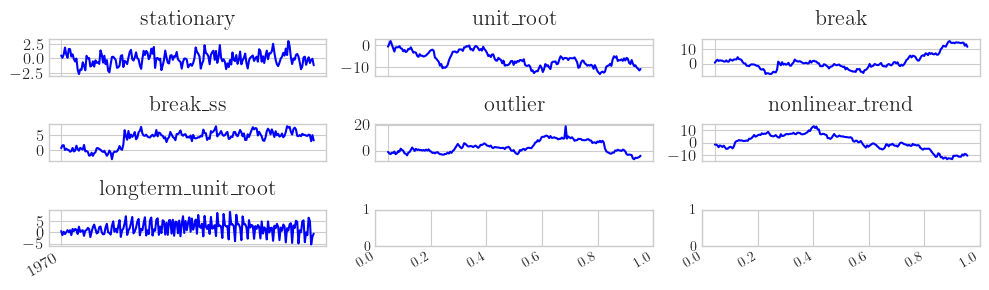

In [31]:
fig, axes = plt.subplots(
    nrows=3, 
    ncols=3, 
    figsize=(10, 3), 
)
fig, axes = plot_utils.plot_series(dataset, fig=fig, axes=axes)
save_figure(fig, './presentation/figures/hw3/simulations.pdf')

## Test 0: LJung Bx 

In [32]:
resultados_ljung_box = testmodule.test_ljungbox(dataset['stationary'], lags=5)
resultados_ljung_box

Test Ljung-Box


,statistic,p-value
0,47.974956,3.593979e-09


## Test 1: DF (Dickey-Fuller)

In [33]:
metrics = testmodule.test_df(dataset['stationary'])

## Test 2: ADF (Augmented Dickey-Fuller)

In [34]:
metrics = testmodule.test_adf(dataset['stationary'], model_type='c')

In [35]:
testmodule.test_adf(dataset['stationary'], max_k=10, model_type='c', alpha=0.05)

,model,statistic,p-value
0,ADF-c,-8.761358,0.01


## Test 3: PP (Phillips-Perron)

In [36]:
metrics = testmodule.test_pp(dataset['longterm_unit_root'])
metrics

,model,statistic,p-value
0,Sin constante ni tendencia,-12.493142,0.01
1,Con constante,-17.455591,0.01
2,Con constante y tendencia,-17.472162,0.01


## Test 4: KPSS (Kwiatkowski-Phillips-Schmidt-Shin)

In [37]:
metrics = testmodule.test_kpss(dataset['stationary'])

## Test 5: Perron

✅ Figura guardada exitosamente en ./presentation/figures/hw3/dummycomparison_du.pdf


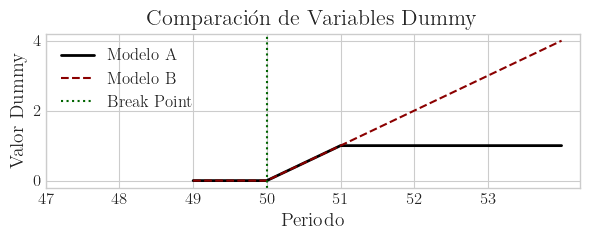

In [43]:
from source.fit.inference.perron import _create_base_regression
# from source.fit.inference.perron import _create_base_regression, create_model_b

# create_model_b(dataset['break'], break_point=50, p=2)[0][:, 3]


input_matrix = _create_base_regression(dataset['break'], break_point=50)

fig, axes = plt.subplots(1, 1, figsize=(6, 2.5), dpi=100)
fig, axes = plot_utils.plot_dummy_comparison(input_matrix, break_point=50, window=3, fig=fig, ax=axes)
save_figure(fig, './presentation/figures/hw3/dummycomparison_du.pdf')

✅ Figura guardada exitosamente en ./presentation/figures/hw3/break_simulation.pdf


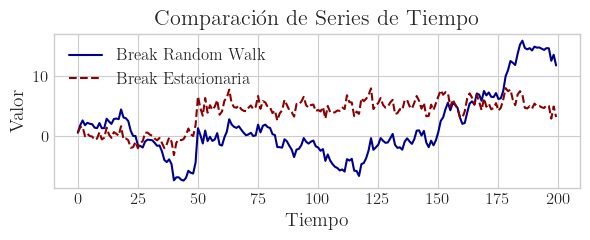

In [148]:
fig, ax = plt.subplots(1, 1, figsize=(6, 2.5))
fig, ax = plot_utils.plot_series_comparison(dataset, fig=fig, ax=ax)
save_figure(fig, './presentation/figures/hw3/break_simulation.pdf')

In [ ]:
metrics = testmodule.test_perron(dataset['break_ss'], break_point=50)


Test Perron


,model,statistic,p-value
0,model_a,-2.831329,0.350339
0,model_b,-4.125009,0.025000
0,model_c,-4.115712,0.047120


## Test 6: Zivot-Andrews

In [ ]:
metrics = testmodule.test_zivot_andrews(dataset['stationary'])

Test Zivot-Andrews


## Test 7: Bierens

In [ ]:
metrics = testmodule.test_bierens(dataset['stationary'])

Test Bierens


In [11]:
testmodule.test_bierens(dataset['unit_root'], max_k=5, max_m=3, alpha=0.05)

,MÃ©trica,Valor
0,EstadÃ­stico (Sesgo Normalizado),-10.039011
1,EstadÃ­stico (t-stat),-2.31465
2,Rezagos Ã“ptimos (k),0
3,Polinomios Ã“ptimos (m),0
4,Valor CrÃ­tico (1%),-3.43
5,Valor CrÃ­tico (5%),-2.86
6,Valor CrÃ­tico (10%),-2.57
7,Nota,El p-valor no se calcula en esta implementaciÃ...


## Test 8: Murray and Nelson

In [ ]:
metrics = testmodule.test_murray_nelson(dataset['stationary'])

Test Murray-Nelson


## Test 9: GLS detrending

In [17]:
metrics = testmodule.test_gls(dataset['stationary'])
metrics

,model,statistic,p-value
0,Intercepto,-6.592506,0.01
